In [137]:
# %%
# ============================================================
# Cell 1. Imports and root path
# ============================================================
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_ROOT = Path("/home/hschatzle/monte-carlo-selection/results/sweep")

In [138]:
# %%
# ============================================================
# Cell 2. Helpers
# ============================================================
def load_jsonl_rows(path: Path):
    rows = []
    with path.open("r") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def parse_condition_from_bgmm_dirname(dirname: str):
    """
    Example:
    bgmm_bird_132_symmetrical_texture_16
      -> network = texture
      -> occ_size = 16

    Assumes the final token is occluder size and the penultimate token is network.
    """
    parts = dirname.split("_")
    if len(parts) < 3:
        return None, None

    network_token = parts[-2].lower()
    occ_token = parts[-1]

    if network_token not in {"texture", "shape"}:
        return None, None

    try:
        occ_size = int(occ_token)
    except ValueError:
        return None, None

    return network_token, occ_size


def latest_jsonl_row(path: Path):
    rows = load_jsonl_rows(path)
    if len(rows) == 0:
        raise ValueError(f"No rows found in {path}")
    return rows[-1]

In [139]:
# %%
# ============================================================
# Cell 3. Discover all fs_hidden_segment.jsonl files
# ============================================================
fs_paths = sorted(RESULTS_ROOT.glob("bgmm_*/*/fs_hidden_segment.jsonl"))

print("n fs_hidden_segment.jsonl files found:", len(fs_paths))
for p in fs_paths[:10]:
    print(p)

n fs_hidden_segment.jsonl files found: 4
/home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_136_symmetrical_shape_16/bird_136_symmetrical_16_1/fs_hidden_segment.jsonl
/home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_136_symmetrical_shape_8/bird_136_symmetrical_8_1/fs_hidden_segment.jsonl
/home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_136_symmetrical_texture_16/bird_136_symmetrical_16_1/fs_hidden_segment.jsonl
/home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_136_symmetrical_texture_8/bird_136_symmetrical_8_1/fs_hidden_segment.jsonl


In [140]:
# %%
# ============================================================
# Cell 4. Build dataframe from all files
# ============================================================
records = []

for fs_path in fs_paths:
    case_dir = fs_path.parent
    bgmm_dir = case_dir.parent

    network, occ_size = parse_condition_from_bgmm_dirname(bgmm_dir.name)
    if network is None or occ_size is None:
        continue

    row = latest_jsonl_row(fs_path)

    record = {
        "fs_path": str(fs_path),
        "bgmm_dir": bgmm_dir.name,
        "case_id": row.get("case_id", case_dir.name),
        "network": network,
        "occ_size": occ_size,

        "segment_key": row.get("segment_key", None),
        "n_points": row.get("n_points", np.nan),
        "arc_length": row.get("arc_length", np.nan),
        "fs_resolution": row.get("fs_resolution", np.nan),
        "fs_signed": row.get("fs_signed", np.nan),
        "fs_baseline_straight": row.get("fs_baseline_straight", np.nan),

        "fs_raw_sum": row.get("fs_raw_sum", np.nan),
        "fs_raw_mean": row.get("fs_raw_mean", np.nan),
        "fs_raw_max": row.get("fs_raw_max", np.nan),
        "fs_raw_min": row.get("fs_raw_min", np.nan),

        "fs_centered_sum": row.get("fs_centered_sum", np.nan),
        "fs_centered_mean": row.get("fs_centered_mean", np.nan),
        "fs_centered_max": row.get("fs_centered_max", np.nan),
        "fs_centered_min": row.get("fs_centered_min", np.nan),
    }
    records.append(record)

df = pd.DataFrame(records)

if len(df) == 0:
    raise ValueError("No valid fs_hidden_segment.jsonl files were parsed.")

df["network"] = pd.Categorical(df["network"], categories=["shape", "texture"], ordered=True)
df["occ_size"] = pd.Categorical(df["occ_size"], categories=[2, 4, 8, 16], ordered=True)

print("n parsed rows:", len(df))
display(df.head())

n parsed rows: 4


,fs_path,bgmm_dir,case_id,network,occ_size,segment_key,n_points,arc_length,fs_resolution,fs_signed,fs_baseline_straight,fs_raw_sum,fs_raw_mean,fs_raw_max,fs_raw_min,fs_centered_sum,fs_centered_mean,fs_centered_max,fs_centered_min
0,/home/hschatzle/monte-carlo-selection/results/...,bgmm_bird_136_symmetrical_shape_16,bird_136_symmetrical_16_1,shape,16,mean_hidden_segment_xy,250,112.730256,3,False,1.073791,263.041645,1.078040,1.618791,1.073791,1.036537,0.004248,0.545000,2.291712e-09
1,/home/hschatzle/monte-carlo-selection/results/...,bgmm_bird_136_symmetrical_shape_8,bird_136_symmetrical_8_1,shape,8,mean_hidden_segment_xy,250,63.223814,3,False,1.073791,263.788518,1.081100,1.732293,1.073791,1.783411,0.007309,0.658501,7.528378e-11
2,/home/hschatzle/monte-carlo-selection/results/...,bgmm_bird_136_symmetrical_texture_16,bird_136_symmetrical_16_1,texture,16,mean_hidden_segment_xy,250,92.668518,3,False,1.073791,263.052602,1.078084,1.790001,1.073791,1.047495,0.004293,0.716210,0.000000e+00
3,/home/hschatzle/monte-carlo-selection/results/...,bgmm_bird_136_symmetrical_texture_8,bird_136_symmetrical_8_1,texture,8,mean_hidden_segment_xy,250,64.639167,3,False,1.073791,263.175700,1.078589,1.467765,1.073791,1.170592,0.004798,0.393973,1.142725e-08


In [141]:
# %%
# ============================================================
# Cell 5. Sanity check, counts per condition
# ============================================================
count_table = (
    df.groupby(["network", "occ_size"], observed=True)
      .size()
      .rename("n_cases")
      .reset_index()
      .sort_values(["network", "occ_size"])
)

display(count_table)

pivot_counts = count_table.pivot(index="network", columns="occ_size", values="n_cases")
display(pivot_counts)

,network,occ_size,n_cases
0,shape,8,1
1,shape,16,1
2,texture,8,1
3,texture,16,1


occ_size,8,16
network,,
shape,1,1
texture,1,1


In [142]:
# %%
# ============================================================
# Cell 6. Aggregate centered FS per condition
# ============================================================
agg = (
    df.groupby(["network", "occ_size"], observed=True)["fs_centered_mean"]
      .agg(["mean", "std", "count"])
      .reset_index()
      .rename(columns={
          "mean": "fs_centered_mean_mean",
          "std": "fs_centered_mean_sd",
          "count": "n"
      })
)

agg["fs_centered_mean_se"] = agg["fs_centered_mean_sd"] / np.sqrt(agg["n"])

display(agg.sort_values(["network", "occ_size"]))

,network,occ_size,fs_centered_mean_mean,fs_centered_mean_sd,n,fs_centered_mean_se
0,shape,8,0.007309,NaN,1,NaN
1,shape,16,0.004248,NaN,1,NaN
2,texture,8,0.004798,NaN,1,NaN
3,texture,16,0.004293,NaN,1,NaN


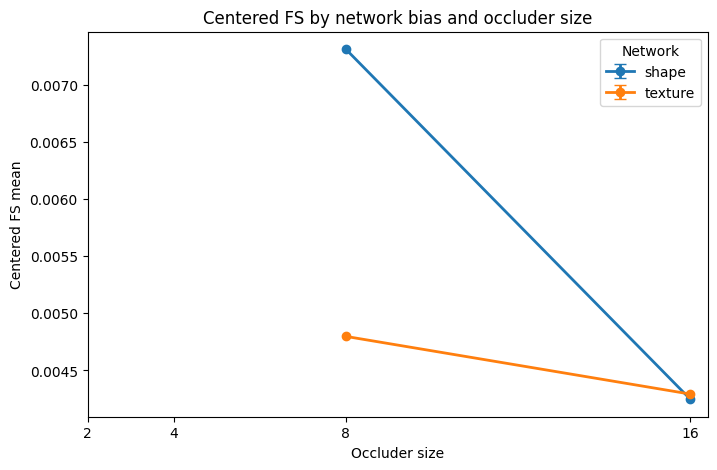

In [143]:
# %%
# ============================================================
# Cell 7. Plot centered FS means with SE bars, 2 x 4 design
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

x_levels = np.array([2, 4, 8, 16], dtype=float)

for network in ["shape", "texture"]:
    sub = (
        agg[agg["network"] == network]
        .sort_values("occ_size")
        .copy()
    )

    x = sub["occ_size"].astype(int).to_numpy()
    y = sub["fs_centered_mean_mean"].to_numpy(dtype=float)
    yerr = sub["fs_centered_mean_se"].to_numpy(dtype=float)

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        marker="o",
        linewidth=2,
        capsize=4,
        label=network
    )

ax.set_xticks(x_levels)
ax.set_xlabel("Occluder size")
ax.set_ylabel("Centered FS mean")
ax.set_title("Centered FS by network bias and occluder size")
ax.legend(title="Network")
plt.show()

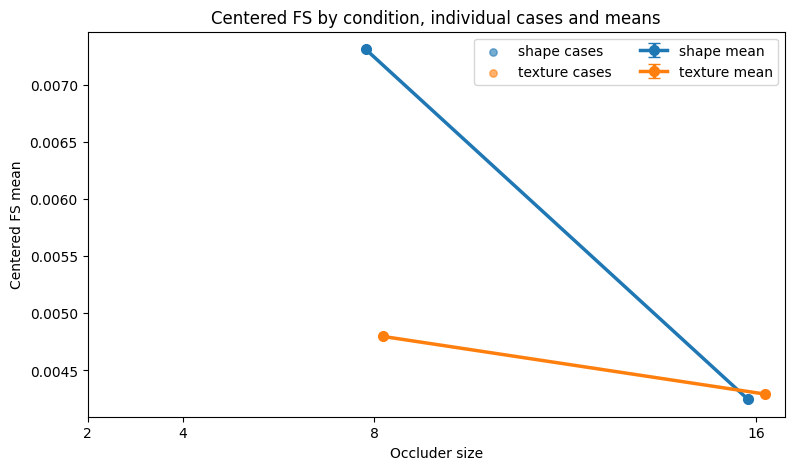

In [144]:
# %%
# ============================================================
# Cell 8. Plot all individual cases + condition means
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5))

offset_map = {"shape": -0.18, "texture": 0.18}

# individual cases
for network in ["shape", "texture"]:
    sub = (
        df[df["network"] == network]
        .sort_values("occ_size")
        .copy()
    )
    x = sub["occ_size"].astype(int).to_numpy(dtype=float) + offset_map[network]
    y = sub["fs_centered_mean"].to_numpy(dtype=float)

    ax.scatter(
        x,
        y,
        s=28,
        alpha=0.6,
        label=f"{network} cases"
    )

# means
for network in ["shape", "texture"]:
    sub = (
        agg[agg["network"] == network]
        .sort_values("occ_size")
        .copy()
    )
    x = sub["occ_size"].astype(int).to_numpy(dtype=float) + offset_map[network]
    y = sub["fs_centered_mean_mean"].to_numpy(dtype=float)
    yerr = sub["fs_centered_mean_se"].to_numpy(dtype=float)

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o-",
        linewidth=2.5,
        capsize=4,
        markersize=7,
        label=f"{network} mean"
    )

ax.set_xticks([2, 4, 8, 16])
ax.set_xlabel("Occluder size")
ax.set_ylabel("Centered FS mean")
ax.set_title("Centered FS by condition, individual cases and means")
ax.legend(ncol=2)
plt.show()

In [145]:
# %%
# Effect size (Cohen's d per occluder size)
def cohens_d(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    na, nb = len(a), len(b)
    sa, sb = np.var(a, ddof=1), np.var(b, ddof=1)
    s = np.sqrt(((na-1)*sa + (nb-1)*sb) / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / s

for occ in [2,4,8,16]:
    a = df[(df.network=="shape") & (df.occ_size==occ)]["fs_centered_mean"]
    b = df[(df.network=="texture") & (df.occ_size==occ)]["fs_centered_mean"]
    print(occ, cohens_d(a, b))

2 nan
4 nan
8 nan
16 nan


/home/hschatzle/monte-carlo-selection/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:4232: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/hschatzle/monte-carlo-selection/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/hschatzle/monte-carlo-selection/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/hschatzle/monte-carlo-selection/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/hschatzle/monte-carlo-selection/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dt

<Axes: xlabel='occ_size', ylabel='fs_centered_mean'>

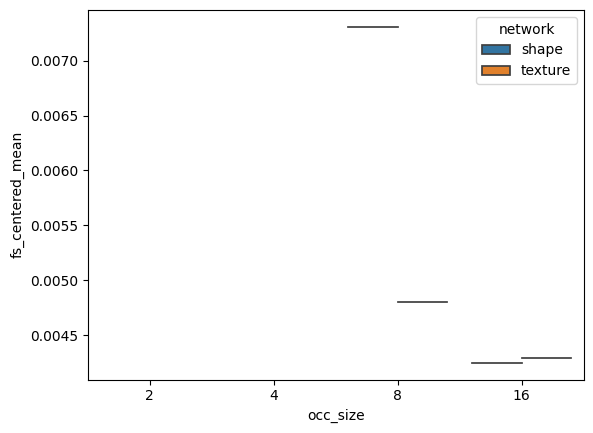

In [146]:
# %%
import seaborn as sns

sns.violinplot(data=df, x="occ_size", y="fs_centered_mean", hue="network", split=True)

In [147]:
# %%
# ============================================================
# Cell. Add stronger FS metrics to df
# ============================================================

df_metrics = df.copy()

# already present
# fs_centered_mean

# ---- max (if not yet saved, fallback = mean as placeholder)
if "fs_centered_max" not in df_metrics.columns:
    print("Warning: fs_centered_max not found, using mean as fallback")
    df_metrics["fs_centered_max"] = df_metrics["fs_centered_mean"]

# ---- density (if not present)
if "fs_centered_density" not in df_metrics.columns:
    if "fs_centered_sum" in df_metrics.columns and "arc_length" in df_metrics.columns:
        df_metrics["fs_centered_density"] = (
            df_metrics["fs_centered_sum"] / df_metrics["arc_length"]
        )
    else:
        print("Warning: cannot compute density, using mean as fallback")
        df_metrics["fs_centered_density"] = df_metrics["fs_centered_mean"]

display(df_metrics.head())

,fs_path,bgmm_dir,case_id,network,occ_size,segment_key,n_points,arc_length,fs_resolution,fs_signed,fs_baseline_straight,fs_raw_sum,fs_raw_mean,fs_raw_max,fs_raw_min,fs_centered_sum,fs_centered_mean,fs_centered_max,fs_centered_min,fs_centered_density
0,/home/hschatzle/monte-carlo-selection/results/...,bgmm_bird_136_symmetrical_shape_16,bird_136_symmetrical_16_1,shape,16,mean_hidden_segment_xy,250,112.730256,3,False,1.073791,263.041645,1.078040,1.618791,1.073791,1.036537,0.004248,0.545000,2.291712e-09,0.009195
1,/home/hschatzle/monte-carlo-selection/results/...,bgmm_bird_136_symmetrical_shape_8,bird_136_symmetrical_8_1,shape,8,mean_hidden_segment_xy,250,63.223814,3,False,1.073791,263.788518,1.081100,1.732293,1.073791,1.783411,0.007309,0.658501,7.528378e-11,0.028208
2,/home/hschatzle/monte-carlo-selection/results/...,bgmm_bird_136_symmetrical_texture_16,bird_136_symmetrical_16_1,texture,16,mean_hidden_segment_xy,250,92.668518,3,False,1.073791,263.052602,1.078084,1.790001,1.073791,1.047495,0.004293,0.716210,0.000000e+00,0.011304
3,/home/hschatzle/monte-carlo-selection/results/...,bgmm_bird_136_symmetrical_texture_8,bird_136_symmetrical_8_1,texture,8,mean_hidden_segment_xy,250,64.639167,3,False,1.073791,263.175700,1.078589,1.467765,1.073791,1.170592,0.004798,0.393973,1.142725e-08,0.018110


In [148]:
# %%
# ============================================================
# Cell. Aggregate all FS metrics
# ============================================================

metrics = [
    "fs_centered_mean",
    "fs_centered_max",
    "fs_centered_density"
]

agg_all = []

for metric in metrics:
    agg = (
        df_metrics
        .groupby(["network", "occ_size"], observed=True)[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    
    agg["metric"] = metric
    agg["se"] = agg["std"] / np.sqrt(agg["count"])
    
    agg_all.append(agg)

agg_all = pd.concat(agg_all, ignore_index=True)

display(agg_all.head())

,network,occ_size,mean,std,count,metric,se
0,shape,8,0.007309,NaN,1,fs_centered_mean,NaN
1,shape,16,0.004248,NaN,1,fs_centered_mean,NaN
2,texture,8,0.004798,NaN,1,fs_centered_mean,NaN
3,texture,16,0.004293,NaN,1,fs_centered_mean,NaN
4,shape,8,0.658501,NaN,1,fs_centered_max,NaN


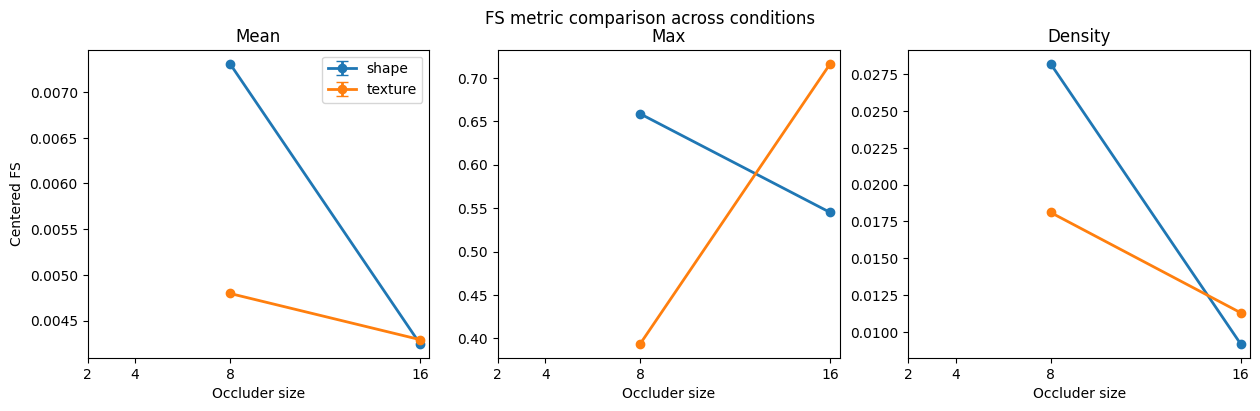

In [149]:
# %%
# ============================================================
# Cell. Multi-panel comparison plot
# ============================================================

metrics_pretty = {
    "fs_centered_mean": "Mean",
    "fs_centered_max": "Max",
    "fs_centered_density": "Density"
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, metric in zip(axes, metrics_pretty.keys()):
    
    sub = agg_all[agg_all["metric"] == metric]
    
    for network in ["shape", "texture"]:
        s = (
            sub[sub["network"] == network]
            .sort_values("occ_size")
        )
        
        x = s["occ_size"].astype(int).to_numpy()
        y = s["mean"].to_numpy()
        yerr = s["se"].to_numpy()
        
        ax.errorbar(
            x, y, yerr=yerr,
            marker="o",
            linewidth=2,
            capsize=4,
            label=network
        )
    
    ax.set_title(metrics_pretty[metric])
    ax.set_xlabel("Occluder size")
    ax.set_xticks([2,4,8,16])
    
axes[0].set_ylabel("Centered FS")
axes[0].legend()

plt.suptitle("FS metric comparison across conditions")
plt.show()

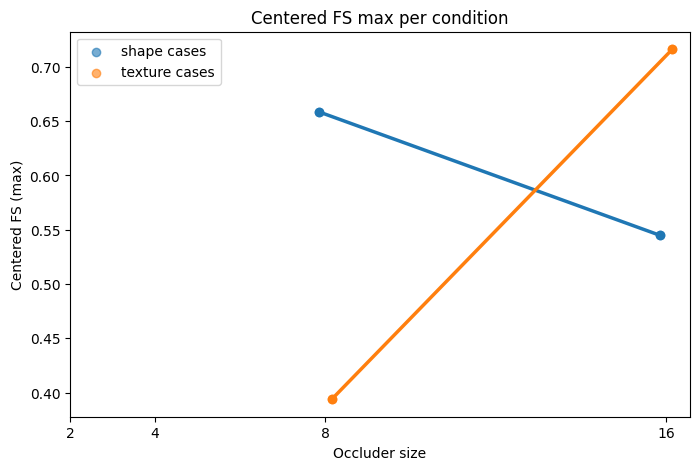

In [150]:
# %%
# ============================================================
# Cell. Individual cases for fs_centered_max
# ============================================================

metric = "fs_centered_max"
offset_map = {"shape": -0.15, "texture": 0.15}

fig, ax = plt.subplots(figsize=(8,5))

# individual points
for network in ["shape", "texture"]:
    sub = df_metrics[df_metrics["network"] == network]
    
    x = sub["occ_size"].astype(int).to_numpy() + offset_map[network]
    y = sub[metric].to_numpy()
    
    ax.scatter(x, y, alpha=0.6, label=f"{network} cases")

# means
for network in ["shape", "texture"]:
    sub = agg_all[
        (agg_all["metric"] == metric) &
        (agg_all["network"] == network)
    ].sort_values("occ_size")
    
    x = sub["occ_size"].astype(int).to_numpy() + offset_map[network]
    y = sub["mean"].to_numpy()
    yerr = sub["se"].to_numpy()
    
    ax.errorbar(x, y, yerr=yerr, fmt="o-", linewidth=2.5, capsize=4)

ax.set_xticks([2,4,8,16])
ax.set_xlabel("Occluder size")
ax.set_ylabel("Centered FS (max)")
ax.set_title("Centered FS max per condition")
ax.legend()
plt.show()

# Yaniv's suggestions

In [151]:
# %%
# ============================================================
# Cell 1. Imports and root path
# ============================================================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_ROOT = Path("/home/hschatzle/monte-carlo-selection/results/sweep")

In [152]:
# %%
# ============================================================
# Cell 2. Helpers
# ============================================================
def parse_condition_from_bgmm_dirname(dirname: str):
    """
    Example:
    bgmm_bird_132_symmetrical_texture_16
      -> network = texture
      -> occ_size = 16
    """
    parts = dirname.split("_")
    if len(parts) < 3:
        return None, None

    network_token = parts[-2].lower()
    occ_token = parts[-1]

    if network_token not in {"shape", "texture"}:
        return None, None

    try:
        occ_size = int(occ_token)
    except ValueError:
        return None, None

    return network_token, occ_size

In [153]:
# %%
# ============================================================
# Cell 3. Discover all pointwise CSVs
# ============================================================
csv_paths = sorted(RESULTS_ROOT.glob("bgmm_*/*/fs_hidden_segment_pointwise.csv"))

print("n pointwise CSVs found:", len(csv_paths))
for p in csv_paths[:10]:
    print(p)

n pointwise CSVs found: 4
/home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_136_symmetrical_shape_16/bird_136_symmetrical_16_1/fs_hidden_segment_pointwise.csv
/home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_136_symmetrical_shape_8/bird_136_symmetrical_8_1/fs_hidden_segment_pointwise.csv
/home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_136_symmetrical_texture_16/bird_136_symmetrical_16_1/fs_hidden_segment_pointwise.csv
/home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_136_symmetrical_texture_8/bird_136_symmetrical_8_1/fs_hidden_segment_pointwise.csv


In [154]:
# %%
# ============================================================
# Cell 4. Build per-case dataframe from pointwise CSVs
# ============================================================
records = []

for csv_path in csv_paths:
    case_dir = csv_path.parent
    bgmm_dir = case_dir.parent

    network, occ_size = parse_condition_from_bgmm_dirname(bgmm_dir.name)
    if network is None or occ_size is None:
        continue

    dfi = pd.read_csv(csv_path)

    # keep only valid points
    if "valid" in dfi.columns:
        dfi_valid = dfi[dfi["valid"] == True].copy()
    else:
        dfi_valid = dfi.copy()

    if len(dfi_valid) == 0:
        continue

    # choose centered FS if present, otherwise fallback to raw
    if "fs_centered" in dfi_valid.columns:
        vals = dfi_valid["fs_centered"].to_numpy(dtype=float)
    elif "fs_raw" in dfi_valid.columns:
        vals = dfi_valid["fs_raw"].to_numpy(dtype=float)
    else:
        continue

    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        continue

    q75 = np.percentile(vals, 75)

    # PI literal version. count above threshold
    high_curv_count_q75 = int(np.sum(vals > q75))

    # weighted version. sum of values above threshold
    high_curv_sum_q75 = float(np.sum(vals[vals > q75]))

    # optional excess-above-threshold version
    high_curv_excess_q75 = float(np.sum(vals[vals > q75] - q75))

    record = {
        "case_id": case_dir.name,
        "network": network,
        "occ_size": occ_size,
        "csv_path": str(csv_path),

        "n_valid": int(len(vals)),
        "q75": float(q75),

        "fs_centered_mean": float(np.mean(vals)),
        "fs_centered_max": float(np.max(vals)),

        "high_curv_count_q75": high_curv_count_q75,
        "high_curv_sum_q75": high_curv_sum_q75,
        "high_curv_excess_q75": high_curv_excess_q75,
    }
    records.append(record)

df_case = pd.DataFrame(records)

df_case["network"] = pd.Categorical(df_case["network"], categories=["shape", "texture"], ordered=True)
df_case["occ_size"] = pd.Categorical(df_case["occ_size"], categories=[2, 4, 8, 16], ordered=True)

print("n cases parsed:", len(df_case))
display(df_case.head())

n cases parsed: 4


,case_id,network,occ_size,csv_path,n_valid,q75,fs_centered_mean,fs_centered_max,high_curv_count_q75,high_curv_sum_q75,high_curv_excess_q75
0,bird_136_symmetrical_16_1,shape,16,/home/hschatzle/monte-carlo-selection/results/...,244,5.457833e-04,0.004248,0.545000,61,1.015243,0.981950
1,bird_136_symmetrical_8_1,shape,8,/home/hschatzle/monte-carlo-selection/results/...,244,2.332302e-04,0.007309,0.658501,61,1.772510,1.758283
2,bird_136_symmetrical_16_1,texture,16,/home/hschatzle/monte-carlo-selection/results/...,244,2.758738e-12,0.004293,0.716210,61,1.047495,1.047495
3,bird_136_symmetrical_8_1,texture,8,/home/hschatzle/monte-carlo-selection/results/...,244,1.073989e-04,0.004798,0.393973,61,1.165759,1.159208


In [155]:
# %%
# ============================================================
# Cell 5. Sanity checks
# ============================================================
display(
    df_case.groupby(["network", "occ_size"], observed=True)
           .size()
           .rename("n_cases")
           .reset_index()
)

display(
    df_case.groupby(["network", "occ_size"], observed=True)[["n_valid", "high_curv_count_q75"]]
           .mean()
           .reset_index()
)

,network,occ_size,n_cases
0,shape,8,1
1,shape,16,1
2,texture,8,1
3,texture,16,1


,network,occ_size,n_valid,high_curv_count_q75
0,shape,8,244.0,61.0
1,shape,16,244.0,61.0
2,texture,8,244.0,61.0
3,texture,16,244.0,61.0


In [156]:
# %%
# ============================================================
# Cell 6. Aggregate metrics by condition
# ============================================================
metrics = [
    "fs_centered_mean",
    "fs_centered_max",
    "high_curv_count_q75",
    "high_curv_sum_q75",
]

agg_rows = []

for metric in metrics:
    agg = (
        df_case.groupby(["network", "occ_size"], observed=True)[metric]
               .agg(["mean", "std", "count"])
               .reset_index()
    )
    agg["metric"] = metric
    agg["se"] = agg["std"] / np.sqrt(agg["count"])
    agg_rows.append(agg)

agg_case = pd.concat(agg_rows, ignore_index=True)
display(agg_case.head())

,network,occ_size,mean,std,count,metric,se
0,shape,8,0.007309,NaN,1,fs_centered_mean,NaN
1,shape,16,0.004248,NaN,1,fs_centered_mean,NaN
2,texture,8,0.004798,NaN,1,fs_centered_mean,NaN
3,texture,16,0.004293,NaN,1,fs_centered_mean,NaN
4,shape,8,0.658501,NaN,1,fs_centered_max,NaN


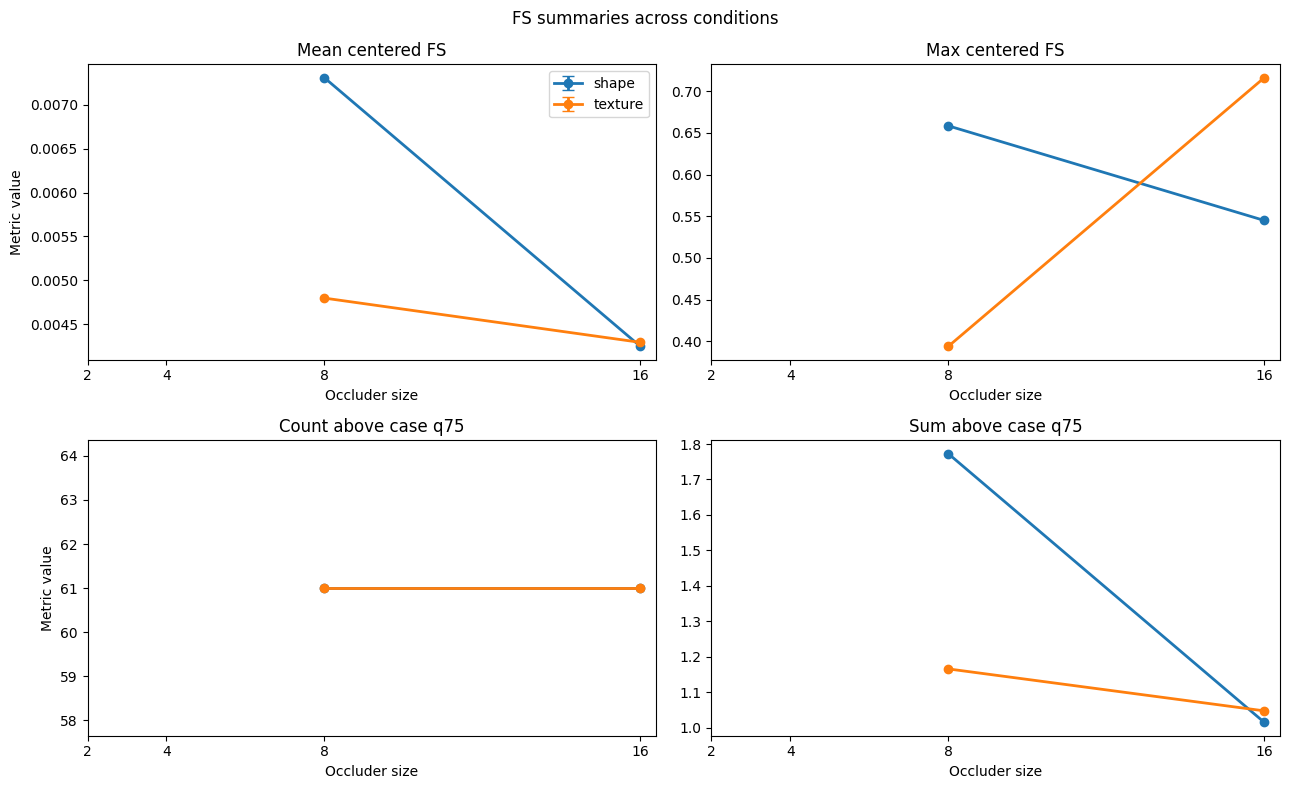

In [157]:
# %%
# ============================================================
# Cell 7. Plot all four metrics
# ============================================================
pretty = {
    "fs_centered_mean": "Mean centered FS",
    "fs_centered_max": "Max centered FS",
    "high_curv_count_q75": "Count above case q75",
    "high_curv_sum_q75": "Sum above case q75",
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()

for ax, metric in zip(axes, pretty.keys()):
    sub = agg_case[agg_case["metric"] == metric].copy()

    for network in ["shape", "texture"]:
        s = sub[sub["network"] == network].sort_values("occ_size")

        x = s["occ_size"].astype(int).to_numpy()
        y = s["mean"].to_numpy(dtype=float)
        yerr = s["se"].to_numpy(dtype=float)

        ax.errorbar(
            x, y, yerr=yerr,
            marker="o",
            linewidth=2,
            capsize=4,
            label=network
        )

    ax.set_title(pretty[metric])
    ax.set_xlabel("Occluder size")
    ax.set_xticks([2, 4, 8, 16])

axes[0].set_ylabel("Metric value")
axes[2].set_ylabel("Metric value")
axes[0].legend()

plt.suptitle("FS summaries across conditions")
plt.tight_layout()
plt.show()

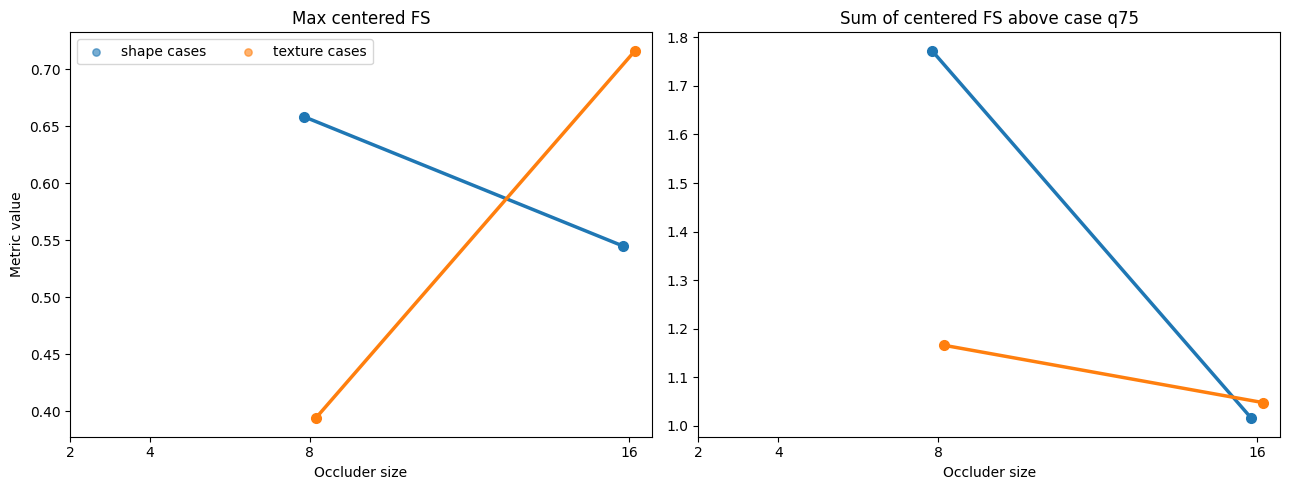

In [158]:
# %%
# ============================================================
# Cell 8. Individual-case plots for the two PI-inspired metrics
# ============================================================
metrics_to_plot = ["fs_centered_max", "high_curv_sum_q75"]
titles = {
    "fs_centered_max": "Max centered FS",
    "high_curv_sum_q75": "Sum of centered FS above case q75",
}
offset_map = {"shape": -0.15, "texture": 0.15}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, metrics_to_plot):
    # individual cases
    for network in ["shape", "texture"]:
        sub = df_case[df_case["network"] == network].copy()
        x = sub["occ_size"].astype(int).to_numpy(dtype=float) + offset_map[network]
        y = sub[metric].to_numpy(dtype=float)

        ax.scatter(x, y, alpha=0.6, s=28, label=f"{network} cases")

    # means
    sub_agg = agg_case[agg_case["metric"] == metric].copy()
    for network in ["shape", "texture"]:
        s = sub_agg[sub_agg["network"] == network].sort_values("occ_size")
        x = s["occ_size"].astype(int).to_numpy(dtype=float) + offset_map[network]
        y = s["mean"].to_numpy(dtype=float)
        yerr = s["se"].to_numpy(dtype=float)

        ax.errorbar(x, y, yerr=yerr, fmt="o-", linewidth=2.5, capsize=4, markersize=7)

    ax.set_title(titles[metric])
    ax.set_xlabel("Occluder size")
    ax.set_xticks([2, 4, 8, 16])

axes[0].set_ylabel("Metric value")
axes[0].legend(ncol=2)
plt.tight_layout()
plt.show()

# Peaks and valleys

In [159]:
# %%
# ============================================================
# Cell 1. Imports and root path
# ============================================================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

RESULTS_ROOT = Path("/home/hschatzle/monte-carlo-selection/results/sweep")

In [160]:
# %%
# ============================================================
# Cell 2. Helpers
# ============================================================
def parse_condition_from_bgmm_dirname(dirname: str):
    """
    Example:
    bgmm_bird_132_symmetrical_texture_16
      -> network = texture
      -> occ_size = 16
    """
    parts = dirname.split("_")
    if len(parts) < 3:
        return None, None

    network_token = parts[-2].lower()
    occ_token = parts[-1]

    if network_token not in {"shape", "texture"}:
        return None, None

    try:
        occ_size = int(occ_token)
    except ValueError:
        return None, None

    return network_token, occ_size

In [161]:
# %%
# ============================================================
# Cell 3. Discover all pointwise CSVs
# ============================================================
csv_paths = sorted(RESULTS_ROOT.glob("bgmm_*/*/fs_hidden_segment_pointwise.csv"))

print("n pointwise CSVs found:", len(csv_paths))
for p in csv_paths[:10]:
    print(p)

n pointwise CSVs found: 4
/home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_136_symmetrical_shape_16/bird_136_symmetrical_16_1/fs_hidden_segment_pointwise.csv
/home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_136_symmetrical_shape_8/bird_136_symmetrical_8_1/fs_hidden_segment_pointwise.csv
/home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_136_symmetrical_texture_16/bird_136_symmetrical_16_1/fs_hidden_segment_pointwise.csv
/home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_136_symmetrical_texture_8/bird_136_symmetrical_8_1/fs_hidden_segment_pointwise.csv


In [162]:
# %%
# ============================================================
# Cell 4. Per-case curvature-change metrics from peaks + valleys
# ============================================================
records = []

for csv_path in csv_paths:
    case_dir = csv_path.parent
    bgmm_dir = case_dir.parent

    network, occ_size = parse_condition_from_bgmm_dirname(bgmm_dir.name)
    if network is None or occ_size is None:
        continue

    dfi = pd.read_csv(csv_path)

    if "valid" in dfi.columns:
        dfi_valid = dfi[dfi["valid"] == True].copy()
    else:
        dfi_valid = dfi.copy()

    if len(dfi_valid) == 0:
        continue

    # Prefer centered FS if available
    if "fs_centered" in dfi_valid.columns:
        vals = dfi_valid["fs_centered"].to_numpy(dtype=float)
    elif "fs_raw" in dfi_valid.columns:
        vals = dfi_valid["fs_raw"].to_numpy(dtype=float)
    else:
        continue

    vals = vals[np.isfinite(vals)]
    if len(vals) < 3:
        continue

    # Literal proxy for PI suggestion:
    # peaks in the FS profile, and valleys via peaks in the negated profile
    peaks, _ = find_peaks(vals)
    valleys, _ = find_peaks(-vals)

    n_peaks = int(len(peaks))
    n_valleys = int(len(valleys))
    num_curvature_changes = int(n_peaks + n_valleys)

    # optional amplitude summaries
    peak_mean = float(np.mean(vals[peaks])) if n_peaks > 0 else np.nan
    valley_mean = float(np.mean(vals[valleys])) if n_valleys > 0 else np.nan
    peak_to_valley_span = (
        float(np.max(vals[peaks]) - np.min(vals[valleys]))
        if (n_peaks > 0 and n_valleys > 0)
        else np.nan
    )

    records.append({
        "case_id": case_dir.name,
        "network": network,
        "occ_size": occ_size,
        "csv_path": str(csv_path),
        "n_valid": int(len(vals)),
        "n_peaks": n_peaks,
        "n_valleys": n_valleys,
        "num_curvature_changes": num_curvature_changes,
        "peak_mean": peak_mean,
        "valley_mean": valley_mean,
        "peak_to_valley_span": peak_to_valley_span,
    })

df_peaks = pd.DataFrame(records)

df_peaks["network"] = pd.Categorical(df_peaks["network"], categories=["shape", "texture"], ordered=True)
df_peaks["occ_size"] = pd.Categorical(df_peaks["occ_size"], categories=[2, 4, 8, 16], ordered=True)

print("n parsed cases:", len(df_peaks))
display(df_peaks.head())

n parsed cases: 4


,case_id,network,occ_size,csv_path,n_valid,n_peaks,n_valleys,num_curvature_changes,peak_mean,valley_mean,peak_to_valley_span
0,bird_136_symmetrical_16_1,shape,16,/home/hschatzle/monte-carlo-selection/results/...,244,49,49,98,0.003761,1.851686e-04,0.144920
1,bird_136_symmetrical_8_1,shape,8,/home/hschatzle/monte-carlo-selection/results/...,244,47,47,94,0.014236,3.952208e-05,0.658501
2,bird_136_symmetrical_16_1,texture,16,/home/hschatzle/monte-carlo-selection/results/...,244,43,43,86,0.000008,1.966076e-13,0.000338
3,bird_136_symmetrical_8_1,texture,8,/home/hschatzle/monte-carlo-selection/results/...,244,48,48,96,0.006792,5.931882e-05,0.319752


In [163]:
# %%
# ============================================================
# Cell 5. Sanity check counts per condition
# ============================================================
display(
    df_peaks.groupby(["network", "occ_size"], observed=True)
            .size()
            .rename("n_cases")
            .reset_index()
)

display(
    df_peaks.groupby(["network", "occ_size"], observed=True)[
        ["n_valid", "n_peaks", "n_valleys", "num_curvature_changes"]
    ]
    .mean()
    .reset_index()
)

,network,occ_size,n_cases
0,shape,8,1
1,shape,16,1
2,texture,8,1
3,texture,16,1


,network,occ_size,n_valid,n_peaks,n_valleys,num_curvature_changes
0,shape,8,244.0,47.0,47.0,94.0
1,shape,16,244.0,49.0,49.0,98.0
2,texture,8,244.0,48.0,48.0,96.0
3,texture,16,244.0,43.0,43.0,86.0


In [164]:
# %%
# ============================================================
# Cell 6. Aggregate peak / valley metrics by condition
# ============================================================
metrics = [
    "n_peaks",
    "n_valleys",
    "num_curvature_changes",
    "peak_to_valley_span",
]

agg_rows = []

for metric in metrics:
    agg = (
        df_peaks.groupby(["network", "occ_size"], observed=True)[metric]
                .agg(["mean", "std", "count"])
                .reset_index()
    )
    agg["metric"] = metric
    agg["se"] = agg["std"] / np.sqrt(agg["count"])
    agg_rows.append(agg)

agg_peaks = pd.concat(agg_rows, ignore_index=True)
display(agg_peaks.head())

,network,occ_size,mean,std,count,metric,se
0,shape,8,47.0,NaN,1,n_peaks,NaN
1,shape,16,49.0,NaN,1,n_peaks,NaN
2,texture,8,48.0,NaN,1,n_peaks,NaN
3,texture,16,43.0,NaN,1,n_peaks,NaN
4,shape,8,47.0,NaN,1,n_valleys,NaN


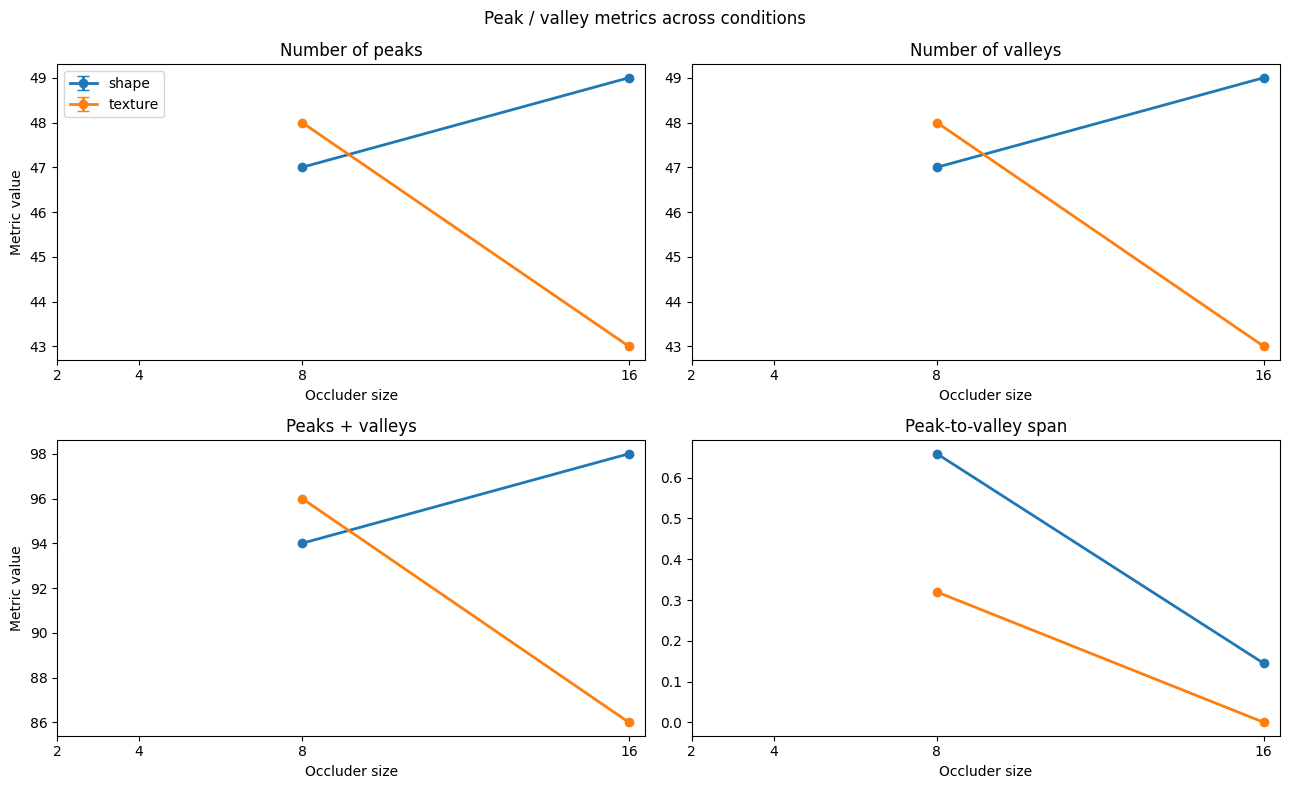

In [165]:
# %%
# ============================================================
# Cell 7. Plot condition means for peak / valley metrics
# ============================================================
pretty = {
    "n_peaks": "Number of peaks",
    "n_valleys": "Number of valleys",
    "num_curvature_changes": "Peaks + valleys",
    "peak_to_valley_span": "Peak-to-valley span",
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()

for ax, metric in zip(axes, pretty.keys()):
    sub = agg_peaks[agg_peaks["metric"] == metric].copy()

    for network in ["shape", "texture"]:
        s = sub[sub["network"] == network].sort_values("occ_size")

        x = s["occ_size"].astype(int).to_numpy()
        y = s["mean"].to_numpy(dtype=float)
        yerr = s["se"].to_numpy(dtype=float)

        ax.errorbar(
            x, y, yerr=yerr,
            marker="o",
            linewidth=2,
            capsize=4,
            label=network
        )

    ax.set_title(pretty[metric])
    ax.set_xlabel("Occluder size")
    ax.set_xticks([2, 4, 8, 16])

axes[0].set_ylabel("Metric value")
axes[2].set_ylabel("Metric value")
axes[0].legend()

plt.suptitle("Peak / valley metrics across conditions")
plt.tight_layout()
plt.show()

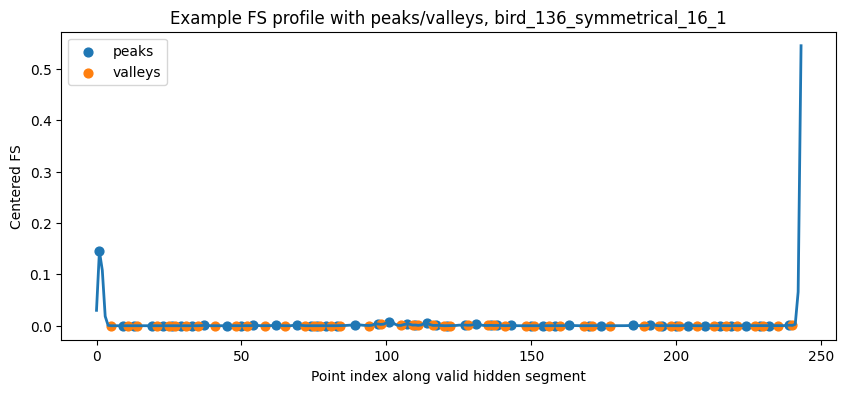

Example case: bird_136_symmetrical_16_1
n_peaks: 49
n_valleys: 49
num_curvature_changes: 98


In [166]:
# %%
# ============================================================
# Cell 9. Inspect one example case visually
# ============================================================
EXAMPLE_CASE_ID = df_peaks.iloc[0]["case_id"]

example_path = None
for p in csv_paths:
    if p.parent.name == EXAMPLE_CASE_ID:
        example_path = p
        break

if example_path is None:
    raise ValueError(f"Could not find CSV for {EXAMPLE_CASE_ID}")

dfi = pd.read_csv(example_path)
if "valid" in dfi.columns:
    dfi = dfi[dfi["valid"] == True].copy()

vals = dfi["fs_centered"].to_numpy(dtype=float) if "fs_centered" in dfi.columns else dfi["fs_raw"].to_numpy(dtype=float)
vals = vals[np.isfinite(vals)]

peaks, _ = find_peaks(vals)
valleys, _ = find_peaks(-vals)

x = np.arange(len(vals))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, vals, linewidth=2)
ax.scatter(peaks, vals[peaks], s=40, label="peaks")
ax.scatter(valleys, vals[valleys], s=40, label="valleys")
ax.set_xlabel("Point index along valid hidden segment")
ax.set_ylabel("Centered FS" if "fs_centered" in dfi.columns else "Raw FS")
ax.set_title(f"Example FS profile with peaks/valleys, {EXAMPLE_CASE_ID}")
ax.legend()
plt.show()

print("Example case:", EXAMPLE_CASE_ID)
print("n_peaks:", len(peaks))
print("n_valleys:", len(valleys))
print("num_curvature_changes:", len(peaks) + len(valleys))

In [167]:
df_peaks["curvature_change_density"] = (
    df_peaks["num_curvature_changes"] / df_peaks["n_valid"]
)

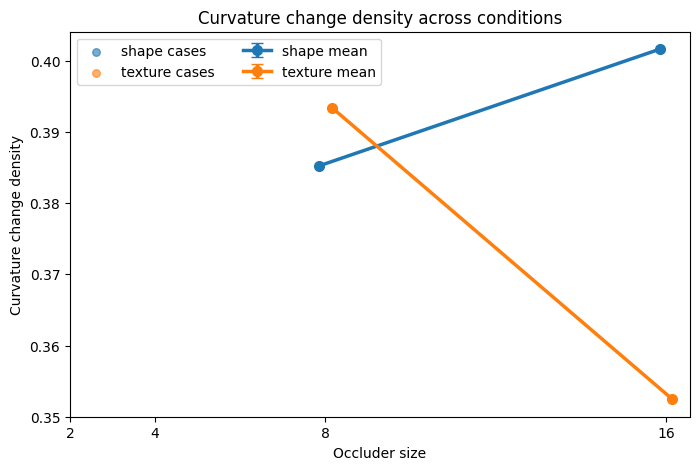

In [168]:
# %%
# ============================================================
# Plot curvature_change_density (means + individual cases)
# ============================================================

metric = "curvature_change_density"
offset_map = {"shape": -0.15, "texture": 0.15}

# aggregate
agg_density = (
    df_peaks
    .groupby(["network", "occ_size"], observed=True)[metric]
    .agg(["mean", "std", "count"])
    .reset_index()
)
agg_density["se"] = agg_density["std"] / np.sqrt(agg_density["count"])

fig, ax = plt.subplots(figsize=(8, 5))

# individual points
for network in ["shape", "texture"]:
    sub = df_peaks[df_peaks["network"] == network]
    x = sub["occ_size"].astype(int).to_numpy(dtype=float) + offset_map[network]
    y = sub[metric].to_numpy(dtype=float)

    ax.scatter(x, y, alpha=0.6, s=30, label=f"{network} cases")

# means + SE
for network in ["shape", "texture"]:
    sub = agg_density[agg_density["network"] == network].sort_values("occ_size")

    x = sub["occ_size"].astype(int).to_numpy(dtype=float) + offset_map[network]
    y = sub["mean"].to_numpy(dtype=float)
    yerr = sub["se"].to_numpy(dtype=float)

    ax.errorbar(
        x, y, yerr=yerr,
        fmt="o-", linewidth=2.5, capsize=4, markersize=7,
        label=f"{network} mean"
    )

ax.set_xticks([2, 4, 8, 16])
ax.set_xlabel("Occluder size")
ax.set_ylabel("Curvature change density")
ax.set_title("Curvature change density across conditions")
ax.legend(ncol=2)

plt.show()

In [169]:
# %%
# ============================================================
# Statistical comparison per occluder size
# ============================================================
from scipy.stats import ttest_ind
import numpy as np

def cohens_d(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    na, nb = len(a), len(b)
    sa, sb = np.var(a, ddof=1), np.var(b, ddof=1)
    s = np.sqrt(((na-1)*sa + (nb-1)*sb) / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / s

print("\n=== Curvature change density: shape vs texture ===\n")

results = []

for occ in [2, 4, 8, 16]:
    a = df_peaks[(df_peaks.network == "shape") & (df_peaks.occ_size == occ)][metric]
    b = df_peaks[(df_peaks.network == "texture") & (df_peaks.occ_size == occ)][metric]

    a = a.dropna()
    b = b.dropna()

    if len(a) < 2 or len(b) < 2:
        continue

    t, p = ttest_ind(a, b, equal_var=False)  # Welch t-test
    d = cohens_d(a, b)

    results.append({
        "occ_size": occ,
        "n_shape": len(a),
        "n_texture": len(b),
        "mean_shape": float(np.mean(a)),
        "mean_texture": float(np.mean(b)),
        "t": float(t),
        "p": float(p),
        "cohens_d": float(d),
    })

results_df = pd.DataFrame(results)
display(results_df)


=== Curvature change density: shape vs texture ===



""


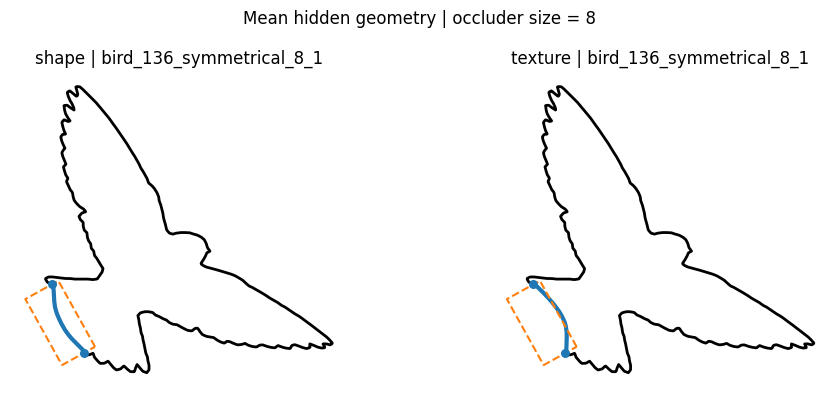

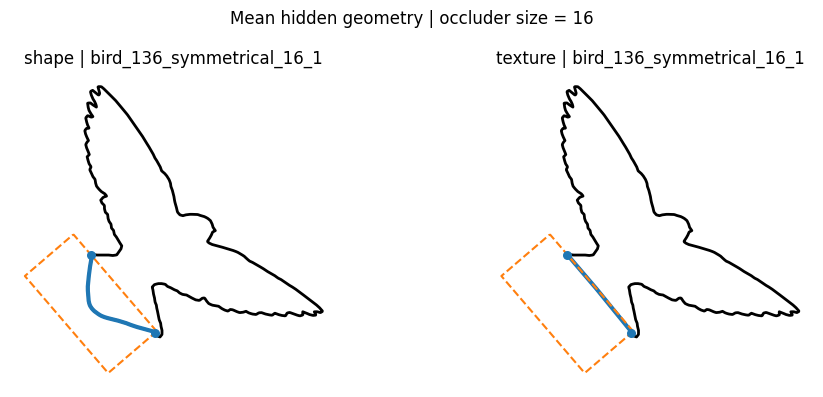

In [170]:
# %%
# ============================================================
# Side-by-side geometry plots (shape vs texture)
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_ROOT = Path("/home/hschatzle/monte-carlo-selection/results/sweep")

def load_geom(jsonl_path):
    with open(jsonl_path, "r", encoding="utf-8") as f:
        record = json.loads(f.readline())

    def arr(key):
        return np.asarray(record[key], dtype=float) if key in record else None

    return {
        "case_id": record.get("case_id", "unknown"),
        "global": arr("global_shape_filled_mean_xy"),
        "hidden": arr("mean_hidden_segment_xy"),
        "occluder": arr("occluder_xy"),
        "intersections": arr("intersection_points_xy"),
    }


# ------------------------------------------------------------
# collect all geometry files
# ------------------------------------------------------------
paths = []

for p in RESULTS_ROOT.glob("bgmm_*/*/mean_hidden_geometry.jsonl"):
    case_id = p.parent.name
    bgmm_dir = p.parent.parent.name

    network, occ_size = parse_condition_from_bgmm_dirname(bgmm_dir)
    if network is None:
        continue

    paths.append({
        "case_id": case_id,
        "network": network,
        "occ_size": occ_size,
        "path": p
    })

df_geom = pd.DataFrame(paths)


# ------------------------------------------------------------
# plotting loop
# ------------------------------------------------------------
for occ in [2, 4, 8, 16]:
    sub = df_geom[df_geom["occ_size"] == occ]

    # find cases present in BOTH networks
    counts = sub.groupby("case_id")["network"].nunique()
    valid_cases = counts[counts == 2].index.tolist()

    if len(valid_cases) == 0:
        continue

    # limit rows for readability
    max_cases = 5
    cases_to_plot = valid_cases[:max_cases]

    n_rows = len(cases_to_plot)
    fig, axes = plt.subplots(n_rows, 2, figsize=(10, 4 * n_rows))

    if n_rows == 1:
        axes = np.array([axes])

    for i, case_id in enumerate(cases_to_plot):
        for j, network in enumerate(["shape", "texture"]):
            ax = axes[i, j]

            row = sub[(sub["case_id"] == case_id) & (sub["network"] == network)]
            if len(row) == 0:
                continue

            geom = load_geom(row.iloc[0]["path"])

            # global shape
            if geom["global"] is not None:
                g = geom["global"]
                ax.plot(g[:,0], g[:,1], color="black", lw=2)

            # hidden segment
            if geom["hidden"] is not None:
                h = geom["hidden"]
                ax.plot(h[:,0], h[:,1], lw=3)

            # occluder
            if geom["occluder"] is not None:
                o = geom["occluder"]
                o = np.vstack([o, o[0]])
                ax.plot(o[:,0], o[:,1], "--", lw=1.5)

            # intersections
            if geom["intersections"] is not None:
                pts = geom["intersections"]
                ax.scatter(pts[:,0], pts[:,1], s=30, zorder=5)

            ax.set_aspect("equal")
            ax.set_title(f"{network} | {case_id}")
            ax.axis("off")

    plt.suptitle(f"Mean hidden geometry | occluder size = {occ}")
    plt.tight_layout()
    plt.show()